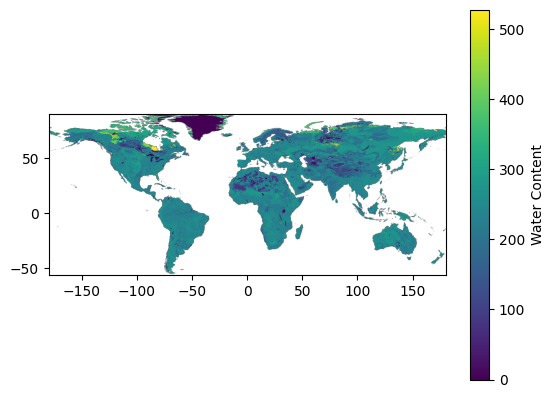

In [10]:
import sys
sys.path.insert(0, r"C:\Users\ktripat\Dropbox\Python_Packages\tmdsi")  
import numpy as np
import matplotlib.pyplot as plt

# Load the data skipping the first 6 lines
# 'unpack=False' ensures it keeps the original grid shape
awc_file = r"E:\Datasets\CPC\Monthly\pawc.dat"
data = np.loadtxt(awc_file, skiprows=6)

# Handle the NoData value (-2)
data[data == -2] = np.nan

# Plot to verify
plt.imshow(data, extent=[-180, 180, -56.5, 90]) # Based on your header info
plt.colorbar(label='Water Content')
plt.show()

In [11]:
import numpy as np
import pandas as pd
from scipy.interpolate import RegularGridInterpolator

# load Webb et al. pawc.dat ONCE
data = np.loadtxt(r"C:\Users\ktripat\Dropbox\Python_Packages\tmdsi\data\pawc.dat", skiprows=6)
data[data == -2] = np.nan

lats_grid = np.linspace(-90, 90,  data.shape[0])
lons_grid = np.linspace(-180, 180, data.shape[1])

interp = RegularGridInterpolator(
    (lats_grid, lons_grid),
    np.flipud(data),
    method='linear', bounds_error=False, fill_value=np.nan
)

# load your CPC latlon
latlon  = pd.read_csv(r"E:\Datasets\CPC\Monthly\latlon.txt", sep='\t', header=None).values
lons_cpc = latlon[:, 0]
lats_cpc = latlon[:, 1]

# ONE vectorized call — all 78016 points in seconds
points  = np.column_stack([lats_cpc, lons_cpc])
awc_all = interp(points)

# save
np.savetxt(r"E:\Datasets\CPC\Monthly\awc_cpc.txt",
           np.column_stack([lons_cpc, lats_cpc, awc_all]),
           fmt="%.4f", delimiter="\t", header="lon\tlat\tawc_mm")
print("Done. AWC saved.")

Done. AWC saved.


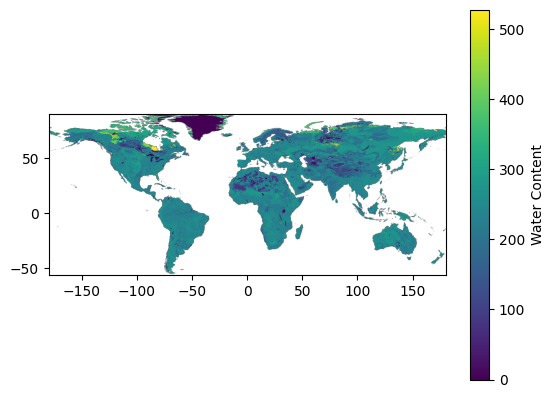

In [16]:
from tmdsi.awc import estimate_awc

lon = -2.75
lat = 33.25
awc_est = estimate_awc(lon, lat)
awc_est

np.float64(228.40103120177474)